# QuantAgent-RL — Forecasting Module Demo

This notebook walks through the three components of the `forecasting` module:

1. **GARCH(1,1) Volatility Forecasting** — per-asset conditional volatility with GPU batch recursion
2. **HMM Regime Detection** — 3-state Gaussian HMM (bear / sideways / bull) with GPU Viterbi decoding
3. **Fama-French Factor Exposures** — rolling OLS with GPU-batched matrix operations
4. **ForecastBundle** — the unified output container consumed by the RL environment

All components use NVIDIA RAPIDS (cuDF / CuPy) when a GPU is available,
falling back transparently to NumPy / SciPy on CPU.

> **Prerequisites**: Run the `data_module_demo.ipynb` first, or set `FRED_API_KEY`
> and let the pipeline fetch data fresh.

In [1]:
import sys
sys.path.insert(0, '..')

import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import matplotlib.patches as mpatches
import seaborn as sns

plt.style.use('seaborn-v0_8-darkgrid')
plt.rcParams.update({'figure.dpi': 120, 'font.size': 10})

SEED = 42
np.random.seed(SEED)
print('Libraries loaded.')

Libraries loaded.


## 0. Generate Synthetic Market Data

We use synthetic data so the notebook runs without API keys.
To use real market data, replace this cell with `DataPipeline.run()` from the data module (see the next three cells).

In [2]:
TICKERS = ['AAPL', 'MSFT', 'NVDA', 'JPM', 'XOM', 'JNJ', 'PG', 'KO', 'NEE', 'CAT']
IDX     = pd.date_range('2010-01-04', '2024-12-31', freq='B')

# # Simulate three distinct volatility regimes to make the HMM interesting
# T = len(IDX)
# regime_vol = np.ones(T) * 0.010         # baseline vol
# # Bear regimes: 2011 (debt crisis), 2015 (China), 2018 (Q4 selloff),
# #               2020 (COVID), 2022 (rate hikes)
# for start, end, vol in [
#     ('2011-07-01','2011-10-01', 0.022),
#     ('2015-08-01','2015-12-01', 0.018),
#     ('2018-10-01','2018-12-31', 0.020),
#     ('2020-02-01','2020-05-01', 0.035),
#     ('2022-01-01','2022-10-01', 0.018),
# ]:
#     mask = (IDX >= start) & (IDX <= end)
#     regime_vol[mask] = vol

# prices = pd.DataFrame(index=IDX, columns=TICKERS, dtype=float)
# for i, ticker in enumerate(TICKERS):
#     drift  = 0.0003 + i * 0.00003
#     factor = np.random.randn(T) * 0.007   # common factor
#     idio   = np.random.randn(T) * regime_vol * (0.8 + i * 0.04)
#     ret    = drift + factor + idio
#     prices[ticker] = 100.0 * np.cumprod(1 + ret)

# log_returns = np.log(prices / prices.shift(1)).dropna()
# split_date  = '2021-12-31'
# train_ret   = log_returns[log_returns.index <= split_date]
# test_ret    = log_returns[log_returns.index >  split_date]
# rebal_train = pd.date_range(train_ret.index[126], train_ret.index[-1], freq='QE')
# rebal_test  = pd.date_range(test_ret.index[0],    test_ret.index[-1],  freq='QE')

# print(f'Universe  : {len(TICKERS)} assets')
# print(f'Train     : {train_ret.index[0].date()} → {train_ret.index[-1].date()} ({len(train_ret)} days)')
# print(f'Test      : {test_ret.index[0].date()} → {test_ret.index[-1].date()} ({len(test_ret)} days)')
# print(f'Train quarters: {len(rebal_train)},  Test quarters: {len(rebal_test)}')

In [3]:
from data import DataConfig, UniverseConfig, DateRangeConfig, FeatureConfig

cfg = DataConfig(
    universe=UniverseConfig(
        tickers=TICKERS,
        benchmark_ticker='SPY',
        min_history_years=5.0,
    ),
    dates=DateRangeConfig(
        start_date=IDX[0].date().isoformat(),
        end_date=IDX[-1].date().isoformat(),
        rebalance_freq='QE',
    ),
    features=FeatureConfig(
        use_gpu=None,   # auto-detect GPU
    ),
)

print('DataConfig:')
print(f'  Tickers      : {len(cfg.universe.tickers)}')
print(f'  Date range   : {cfg.dates.start_date} → {cfg.dates.end_date}')
print(f'  FRED API key : {"set" if cfg.macro.api_key else "NOT SET — set FRED_API_KEY env var"}')

DataConfig:
  Tickers      : 10
  Date range   : 2010-01-04 → 2024-12-31
  FRED API key : set


In [4]:
from data import DataPipeline

pipeline = DataPipeline(cfg)
pipeline.run(
    skip_sec=False,       # Set False to download SEC filings (slow first run)
    use_cache=True,      # Use cached parquet files if available
    force_refresh=True, # Set True to re-download all data
)

pipeline.summary()

2026-03-29 15:56:43 [INFO] data.pipeline: ============================================================
2026-03-29 15:56:43 [INFO] data.pipeline: QuantAgent-RL Data Pipeline
2026-03-29 15:56:43 [INFO] data.pipeline: ============================================================
2026-03-29 15:56:43 [INFO] data.pipeline: [Pipeline] Stage 1: Market data ingestion
2026-03-29 15:56:43 [INFO] data.ingestion: [MarketData] Downloading batch 1/1: ['AAPL', 'MSFT', 'NVDA', 'JPM', 'XOM', 'JNJ', 'PG', 'KO', 'NEE', 'CAT', 'SPY']
2026-03-29 15:56:44 [INFO] data.pipeline: [Pipeline] Market data: 11 tickers, 3773 trading days (2010-01-04 → 2024-12-30)
2026-03-29 15:56:44 [INFO] data.pipeline: [Pipeline] Stage 2: Macro data ingestion
2026-03-29 15:56:44 [INFO] data.ingestion: [MacroData] Fetching FEDFUNDS → fed_funds_rate
2026-03-29 15:56:44 [INFO] data.ingestion: [MacroData] Fetching CPIAUCSL → cpi_yoy
2026-03-29 15:56:45 [INFO] data.ingestion: [MacroData] Fetching DCOILWTICO → wti_crude_oil
2026-03-29 15

QuantAgent-RL Data Pipeline Summary
Universe          : 10 assets
Date range        : 2010-01-04 → 2024-12-31
Rebalance freq    : QE
Rebalance dates   : 60
Walk-forward folds: 12
Macro signals     : 26
SEC filings       : 222
Feature matrix    : (60, 140)
GPU backend       : None

Sector distribution:
sector
Information Technology    3
Consumer Staples          2
Financials                1
Energy                    1
Health Care               1
Utilities                 1
Industrials               1

Walk-forward folds:
  WalkForwardFold(fold=0, train=2010-03-31→2012-12-31 (12Q), test=2013-03-31→2013-12-31 (4Q), n_assets=10)
  WalkForwardFold(fold=1, train=2010-03-31→2013-12-31 (16Q), test=2014-03-31→2014-12-31 (4Q), n_assets=10)
  WalkForwardFold(fold=2, train=2010-03-31→2014-12-31 (20Q), test=2015-03-31→2015-12-31 (4Q), n_assets=10)
  WalkForwardFold(fold=3, train=2010-03-31→2015-12-31 (24Q), test=2016-03-31→2016-12-31 (4Q), n_assets=10)
  WalkForwardFold(fold=4, train=2010-03-31→20

In [5]:
log_returns = np.log(pipeline.all_prices / pipeline.all_prices.shift(1)).dropna()
split_date  = '2021-12-31'
train_ret   = log_returns[log_returns.index <= split_date]
test_ret    = log_returns[log_returns.index >  split_date]
rebal_train = pd.date_range(train_ret.index[126], train_ret.index[-1], freq='QE')
rebal_test  = pd.date_range(test_ret.index[0],    test_ret.index[-1],  freq='QE')

print(f'Universe  : {len(TICKERS)} assets')
print(f'Train     : {train_ret.index[0].date()} → {train_ret.index[-1].date()} ({len(train_ret)} days)')
print(f'Test      : {test_ret.index[0].date()} → {test_ret.index[-1].date()} ({len(test_ret)} days)')
print(f'Train quarters: {len(rebal_train)},  Test quarters: {len(rebal_test)}')

Universe  : 10 assets
Train     : 2010-01-05 → 2021-12-31 (3020 days)
Test      : 2022-01-03 → 2024-12-30 (752 days)
Train quarters: 46,  Test quarters: 11


## 1. GARCH(1,1) Volatility Forecasting

### 1a. Configuration

In [6]:
from forecasting import GARCHForecaster, GARCHConfig

garch_cfg = GARCHConfig(
    p=1, q=1,
    dist='t',           # 't' gives heavier tails when arch library is installed
    rescale=True,       # multiply returns by 100 for numerical conditioning
    horizon=63,         # 1-quarter-ahead forecast (≈ 63 trading days)
    annualize=True,     # return annualized vol
    min_obs=252,        # require 1 year of history before fitting
    use_gpu=None,       # auto-detect GPU
    refit_every_n_quarters=4,
)

gf = GARCHForecaster(garch_cfg)
gf.fit(train_ret)
params = gf.parameter_summary()
print('GARCH(1,1) fitted parameters:')
print(params[['omega','alpha','beta','persistence','long_run_vol','half_life_days','converged']].round(4))

2026-03-29 15:56:47 [INFO] forecasting.garch: [GARCH] Backend: CPU (NumPy)
2026-03-29 15:56:47 [INFO] forecasting.garch: [GARCH] Fitting 10 assets on 3020 observations (2010-01-05 → 2021-12-31)
2026-03-29 15:56:47 [INFO] forecasting.garch: [GARCH] Fit complete: 10/10 converged.


GARCH(1,1) fitted parameters:
         omega     alpha      beta persistence long_run_vol half_life_days  \
AAPL  0.140384  0.114357  0.847513     0.96187     0.304597      17.829689   
MSFT  0.118961  0.123309  0.833676    0.956985     0.263991      15.764794   
NVDA  0.085234  0.066147  0.926637    0.992784     0.545578      95.709985   
JPM    0.06632  0.101521   0.87782     0.97934      0.28442       33.20305   
XOM    0.02096  0.086246  0.906185     0.99243     0.264157      91.222077   
JNJ     0.0553  0.123782  0.826181    0.949963     0.166885      13.503136   
PG    0.087222  0.132674  0.786432    0.919106     0.164837       8.217161   
KO    0.043139  0.092417  0.870332    0.962749     0.170831      18.258712   
NEE    0.03887  0.078694  0.892134    0.970828      0.18324      23.412053   
CAT   0.057533   0.07554  0.910913    0.986453     0.327137       50.81734   

     converged  
AAPL      True  
MSFT      True  
NVDA      True  
JPM       True  
XOM       True  
JNJ      

### 1b. Parameter Diagnostics

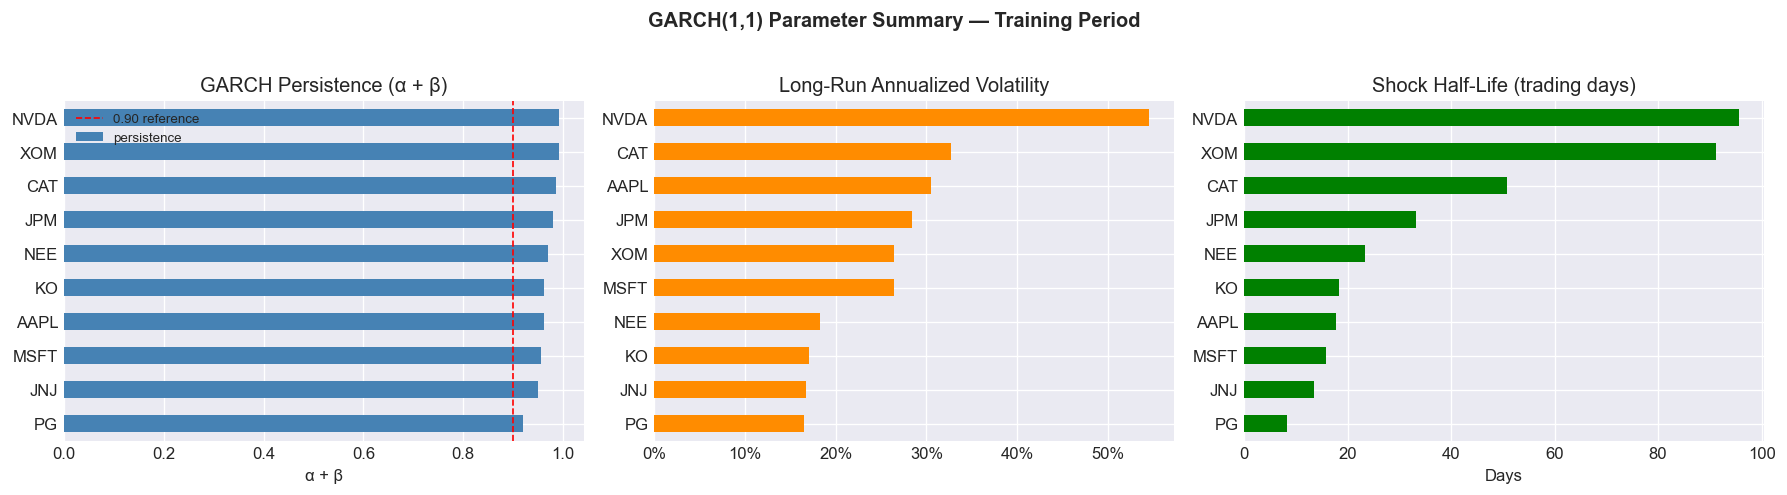

In [7]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# Persistence (α + β)
params['persistence'].sort_values().plot.barh(ax=axes[0], color='steelblue')
axes[0].axvline(0.9, color='red', linestyle='--', linewidth=1, label='0.90 reference')
axes[0].set_title('GARCH Persistence (α + β)')
axes[0].set_xlabel('α + β')
axes[0].legend(fontsize=8)

# Long-run annualized volatility
params['long_run_vol'].sort_values().plot.barh(ax=axes[1], color='darkorange')
axes[1].set_title('Long-Run Annualized Volatility')
axes[1].xaxis.set_major_formatter(mtick.PercentFormatter(xmax=1))

# Half-life of a volatility shock
params['half_life_days'].sort_values().plot.barh(ax=axes[2], color='green')
axes[2].set_title('Shock Half-Life (trading days)')
axes[2].set_xlabel('Days')

plt.suptitle('GARCH(1,1) Parameter Summary — Training Period', y=1.02, fontweight='bold')
plt.tight_layout()
plt.show()

### 1c. Quarterly Volatility Forecasts

2026-03-29 15:56:47 [INFO] forecasting.garch: [GARCH] Fitting 10 assets on 313 observations (2010-01-05 → 2011-03-31)
2026-03-29 15:56:47 [INFO] forecasting.garch: [GARCH] Fit complete: 10/10 converged.
2026-03-29 15:56:47 [INFO] forecasting.garch: [GARCH] Fitting 10 assets on 565 observations (2010-01-05 → 2012-03-30)
2026-03-29 15:56:47 [INFO] forecasting.garch: [GARCH] Fit complete: 10/10 converged.
2026-03-29 15:56:47 [INFO] forecasting.garch: [GARCH] Fitting 10 assets on 813 observations (2010-01-05 → 2013-03-28)
2026-03-29 15:56:47 [INFO] forecasting.garch: [GARCH] Fit complete: 10/10 converged.
2026-03-29 15:56:47 [INFO] forecasting.garch: [GARCH] Fitting 10 assets on 1066 observations (2010-01-05 → 2014-03-31)
2026-03-29 15:56:48 [INFO] forecasting.garch: [GARCH] Fit complete: 10/10 converged.
2026-03-29 15:56:48 [INFO] forecasting.garch: [GARCH] Fitting 10 assets on 1318 observations (2010-01-05 → 2015-03-31)
2026-03-29 15:56:48 [INFO] forecasting.garch: [GARCH] Fit complete: 

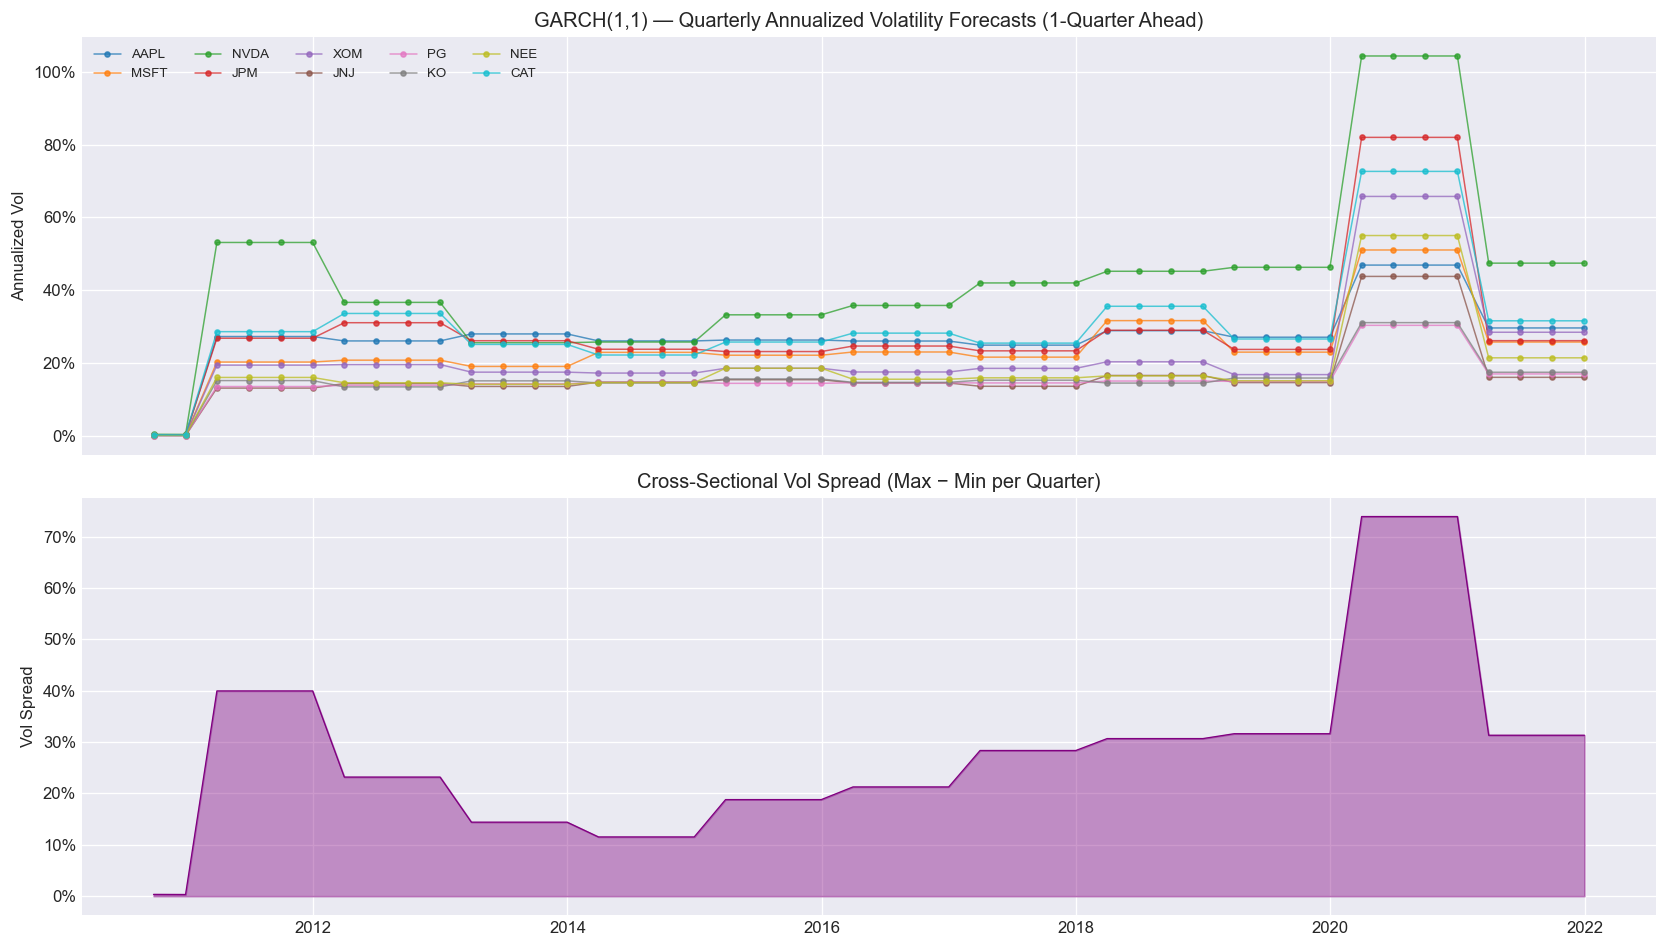

Quarterly vol shape: (46, 10)


In [8]:
quarterly_vol = gf.forecast_quarterly(train_ret, rebal_train)

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 8), sharex=True)

# Time series of quarterly vol forecasts
for col in quarterly_vol.columns:
    ax1.plot(quarterly_vol.index, quarterly_vol[col], marker='o', markersize=3,
             linewidth=0.9, alpha=0.75, label=col)
ax1.yaxis.set_major_formatter(mtick.PercentFormatter(xmax=1))
ax1.set_title('GARCH(1,1) — Quarterly Annualized Volatility Forecasts (1-Quarter Ahead)')
ax1.set_ylabel('Annualized Vol')
ax1.legend(loc='upper left', ncol=5, fontsize=8)

# Cross-sectional vol spread (max - min) per quarter
vol_spread = quarterly_vol.max(axis=1) - quarterly_vol.min(axis=1)
ax2.fill_between(vol_spread.index, vol_spread, alpha=0.4, color='purple')
ax2.plot(vol_spread.index, vol_spread, color='purple', linewidth=0.8)
ax2.yaxis.set_major_formatter(mtick.PercentFormatter(xmax=1))
ax2.set_title('Cross-Sectional Vol Spread (Max − Min per Quarter)')
ax2.set_ylabel('Vol Spread')

plt.tight_layout()
plt.show()
print(f'Quarterly vol shape: {quarterly_vol.shape}')

## 2. HMM Regime Detection

### 2a. Fit and Inspect Parameters

In [9]:
from forecasting import RegimeDetector, RegimeConfig

regime_cfg = RegimeConfig(
    n_states=3,
    n_iter=200,
    covariance_type='diag',
    random_state=SEED,
    lookback_window=252,
    use_gpu=None,
)

rd = RegimeDetector(regime_cfg)
rd.fit(train_ret)

print('State label map (sorted by mean market return):')
print(rd._label_map)

print('\nHMM Transition Matrix:')
trans = rd.transition_matrix()
print(trans.round(3))

print('\nIn-Sample State Statistics:')
stats = rd.state_statistics(train_ret)
print(stats.round(4))

2026-03-29 15:56:48 [INFO] forecasting.regime: [Regime] Backend: CPU (NumPy)
2026-03-29 15:56:48 [INFO] forecasting.regime: [Regime] Fitting HMM (3 states) on 3020 obs (2010-01-05 → 2021-12-31)
2026-03-29 15:56:49 [INFO] forecasting.regime: [Regime] hmmlearn fit complete. Converged: True, Log-likelihood: -6849.45


State label map (sorted by mean market return):
{0: 'bear', 1: 'sideways', 2: 'bull'}

HMM Transition Matrix:
           bear  sideways   bull
bear      0.544     0.406  0.050
sideways  0.047     0.691  0.262
bull      0.014     0.204  0.781

In-Sample State Statistics:
          mean_return_ann  vol_ann  sharpe_ann  frequency
bear              -0.8773   0.5029     -1.7445     0.0497
sideways           0.1684   0.1847      0.9117     0.4033
bull               0.2575   0.0790      3.2576     0.5470


### 2b. Transition Matrix Heatmap

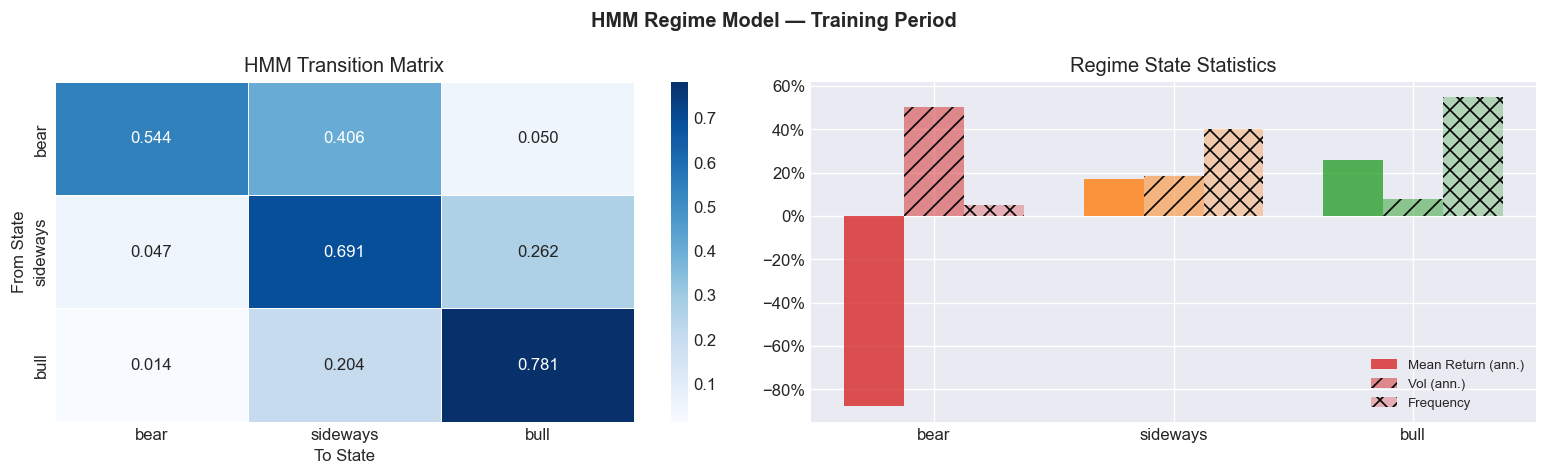

In [10]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 4))

sns.heatmap(
    trans, annot=True, fmt='.3f', cmap='Blues',
    ax=ax1, cbar=True, linewidths=0.5,
    xticklabels=trans.columns, yticklabels=trans.index
)
ax1.set_title('HMM Transition Matrix')
ax1.set_xlabel('To State')
ax1.set_ylabel('From State')

# State statistics bar chart
stats_plot = stats[['mean_return_ann', 'vol_ann', 'frequency']].copy()
x = np.arange(len(stats_plot))
w = 0.25
colors = {'bear': '#d62728', 'sideways': '#ff7f0e', 'bull': '#2ca02c'}
bar_colors = [colors.get(lbl, 'steelblue') for lbl in stats_plot.index]

bars1 = ax2.bar(x - w, stats_plot['mean_return_ann'], w, label='Mean Return (ann.)', color=bar_colors, alpha=0.8)
bars2 = ax2.bar(x,      stats_plot['vol_ann'],         w, label='Vol (ann.)',         color=bar_colors, alpha=0.5, hatch='//')
bars3 = ax2.bar(x + w,  stats_plot['frequency'],       w, label='Frequency',          color=bar_colors, alpha=0.3, hatch='xx')

ax2.set_xticks(x)
ax2.set_xticklabels(stats_plot.index)
ax2.yaxis.set_major_formatter(mtick.PercentFormatter(xmax=1))
ax2.set_title('Regime State Statistics')
ax2.legend(fontsize=8)

plt.suptitle('HMM Regime Model — Training Period', fontweight='bold')
plt.tight_layout()
plt.show()

### 2c. Regime Sequence Over Time

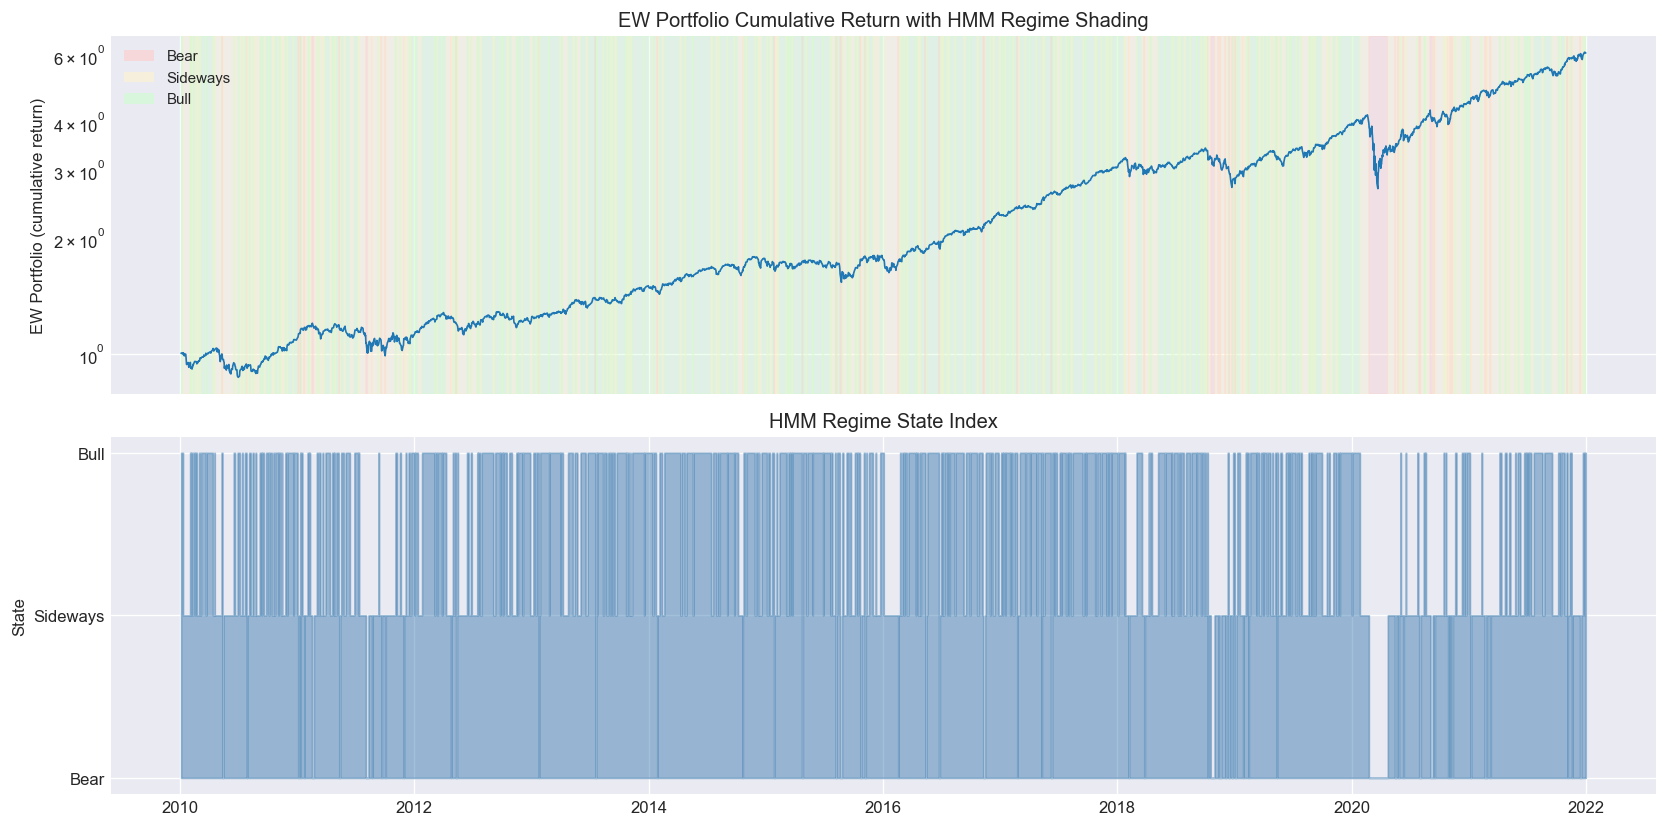

In [11]:
# Decode the full regime sequence over the training history
state_seq = rd.decode_sequence(train_ret)   # (T,) integer array, sorted
state_labels_seq = [rd._label_map[s] for s in state_seq]

# Equally-weighted portfolio cumulative return
ew_ret = train_ret.mean(axis=1)
ew_cum = (1 + ew_ret).cumprod()

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 7), sharex=True)

# Cumulative return with regime shading
colors_map = {'bear': '#ffcccc', 'sideways': '#fff3cc', 'bull': '#ccffcc'}
prev_regime = state_labels_seq[0]
prev_i = 0
for i, (date, regime) in enumerate(zip(train_ret.index, state_labels_seq)):
    if regime != prev_regime or i == len(state_labels_seq) - 1:
        ax1.axvspan(
            train_ret.index[prev_i], date,
            alpha=0.3, color=colors_map[prev_regime], label=None
        )
        prev_regime, prev_i = regime, i

ax1.plot(train_ret.index, ew_cum.values, color='#1f77b4', linewidth=1.0)
ax1.set_ylabel('EW Portfolio (cumulative return)')
ax1.set_yscale('log')
legend_patches = [
    mpatches.Patch(facecolor='#ffcccc', alpha=0.6, label='Bear'),
    mpatches.Patch(facecolor='#fff3cc', alpha=0.6, label='Sideways'),
    mpatches.Patch(facecolor='#ccffcc', alpha=0.6, label='Bull'),
]
ax1.legend(handles=legend_patches, loc='upper left', fontsize=9)
ax1.set_title('EW Portfolio Cumulative Return with HMM Regime Shading')

# Regime index over time
state_int = pd.Series(state_seq, index=train_ret.index)
ax2.fill_between(state_int.index, state_int, step='post', alpha=0.5,
                 color='steelblue')
ax2.set_yticks([0, 1, 2])
ax2.set_yticklabels(['Bear', 'Sideways', 'Bull'])
ax2.set_title('HMM Regime State Index')
ax2.set_ylabel('State')

plt.tight_layout()
plt.show()

### 2d. Quarterly Regime Forecasts

Quarterly regime DataFrame (last 8 quarters):
           regime_label  regime_index    p_bear  p_sideways        p_bull
date                                                                     
2020-03-31         bear             0  0.831162    0.168838  4.583688e-11
2020-06-30     sideways             1  0.009447    0.706503  2.840498e-01
2020-09-30     sideways             1  0.004307    0.640797  3.548961e-01
2020-12-31         bull             2  0.000450    0.077218  9.223324e-01
2021-03-31     sideways             1  0.011979    0.983228  4.793317e-03
2021-06-30         bull             2  0.000429    0.049608  9.499628e-01
2021-09-30     sideways             1  0.006208    0.685845  3.079463e-01
2021-12-31         bull             2  0.000229    0.026538  9.732330e-01


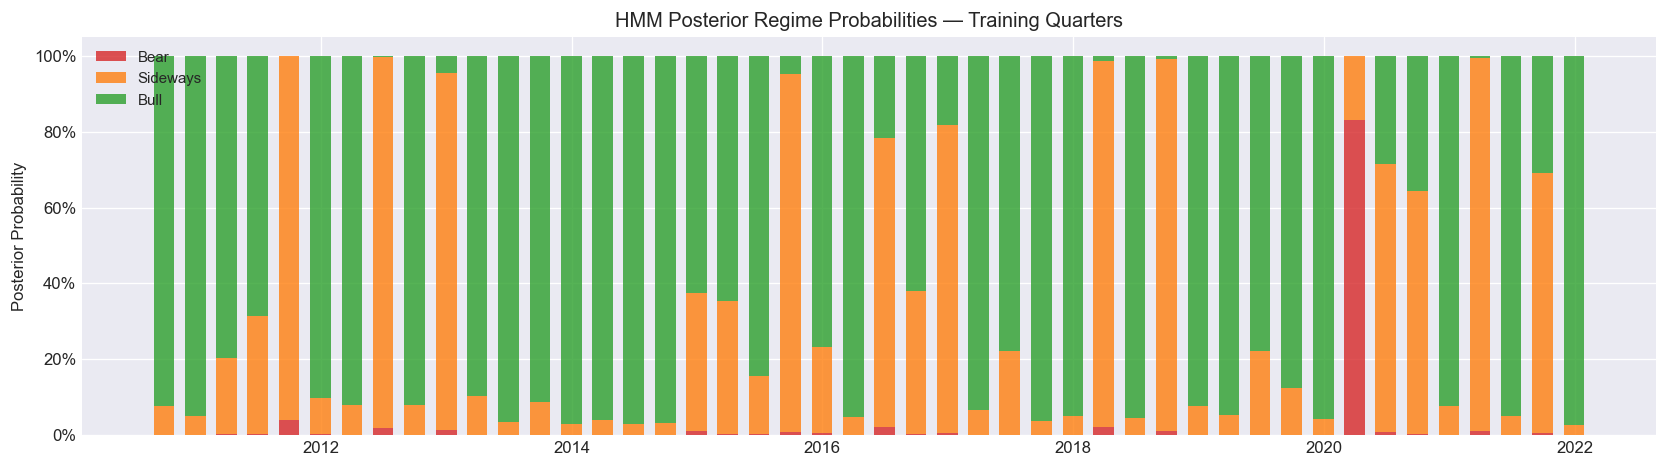

In [12]:
quarterly_regime = rd.forecast_quarterly(train_ret, rebal_train)
print('Quarterly regime DataFrame (last 8 quarters):')
print(quarterly_regime.tail(8).to_string())

fig, ax = plt.subplots(figsize=(14, 4))

prob_cols = [c for c in quarterly_regime.columns if c.startswith('p_')]
bottom = np.zeros(len(quarterly_regime))
palette = ['#d62728', '#ff7f0e', '#2ca02c', '#9467bd']  # bear, sideways, bull, extra
for col, color in zip(prob_cols, palette):
    vals = quarterly_regime[col].values
    ax.bar(quarterly_regime.index, vals, bottom=bottom,
           width=60, color=color, alpha=0.8,
           label=col.replace('p_', '').title())
    bottom += vals

ax.set_ylim(0, 1.05)
ax.yaxis.set_major_formatter(mtick.PercentFormatter(xmax=1))
ax.set_title('HMM Posterior Regime Probabilities — Training Quarters')
ax.set_ylabel('Posterior Probability')
ax.legend(loc='upper left', fontsize=9)
plt.tight_layout()
plt.show()

## 3. Fama-French Factor Exposures

### 3a. Load Factors

Factor data is downloaded for free from Ken French's Data Library
(`https://mba.tuck.dartmouth.edu`) and cached locally.

If no internet connection is available, we inject synthetic factor data below.

In [13]:
from forecasting import FamaFrenchFactors, FamaFrenchConfig

ff_cfg = FamaFrenchConfig(
    n_factors=3,
    rolling_window=63,      # 1-quarter rolling OLS window
    min_obs_fraction=0.8,
    cache_dir='../data/cache/ff_factors',
    use_gpu=None,
    annualize_alpha=True,
)

ff = FamaFrenchFactors(ff_cfg)

# Try loading real FF factors; fall back to synthetic data for offline demo
try:
    ff.load_factors(use_cache=True)
    print('Fama-French factors loaded from Ken French Data Library.')
except Exception as e:
    print(f'Could not load FF factors ({e}). Using synthetic factor data for demo.')
    n = len(log_returns)
    np.random.seed(0)
    ff._ff_data = pd.DataFrame({
        'mkt_rf': np.random.randn(n) * 0.008,
        'smb':    np.random.randn(n) * 0.004,
        'hml':    np.random.randn(n) * 0.004,
        'rf':     np.full(n, 0.00015),
    }, index=log_returns.index)

2026-03-29 15:56:50 [INFO] forecasting.factors: [FF3] Backend: CPU (NumPy)
2026-03-29 15:56:50 [INFO] forecasting.factors: [FF] Loading FF3 from cache.
2026-03-29 15:56:50 [INFO] forecasting.factors: [FF3] Factors loaded: 1926-07-01 → 2026-01-30


Fama-French factors loaded from Ken French Data Library.


### 3b. Full-History Factor Summary

Fama-French Factor Summary (full training history):
      alpha_ann  beta_mkt  beta_smb  beta_hml  r_squared
AAPL     0.0849    1.1334   -0.2469   -0.5054     0.4832
MSFT     0.0287    1.1575   -0.3979   -0.4708     0.6197
NVDA     0.0899    1.5323    0.2362   -0.8121     0.4297
JPM     -0.0139    1.1678   -0.1956    1.0571     0.7763
XOM     -0.0875    0.8849   -0.0754    0.7434     0.5892
JNJ      0.0074    0.6572   -0.3879   -0.0512     0.4375
PG       0.0190    0.6070   -0.5231   -0.0149     0.3854
KO      -0.0026    0.6452   -0.4029    0.1658     0.4279
NEE      0.0865    0.6745   -0.3985   -0.0546     0.3246
CAT     -0.0255    1.1081    0.2154    0.5363     0.5684


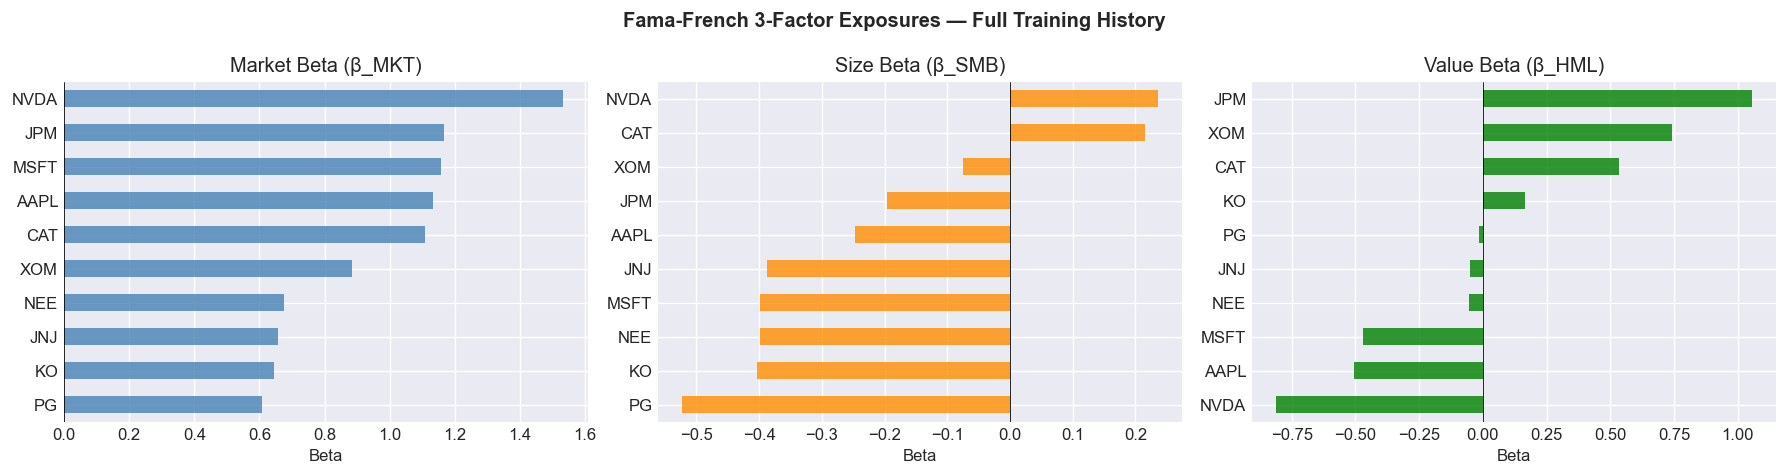

In [14]:
summary = ff.factor_summary(train_ret)
print('Fama-French Factor Summary (full training history):')
print(summary.round(4))

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

for ax, col, color, title in zip(
    axes,
    ['beta_mkt', 'beta_smb', 'beta_hml'],
    ['steelblue', 'darkorange', 'green'],
    ['Market Beta (β_MKT)', 'Size Beta (β_SMB)', 'Value Beta (β_HML)'],
):
    if col not in summary.columns:
        continue
    summary[col].sort_values().plot.barh(ax=ax, color=color, alpha=0.8)
    ax.axvline(0, color='black', linewidth=0.5)
    ax.set_title(title)
    ax.set_xlabel('Beta')

plt.suptitle('Fama-French 3-Factor Exposures — Full Training History', fontweight='bold')
plt.tight_layout()
plt.show()

### 3c. Rolling Beta Heatmap

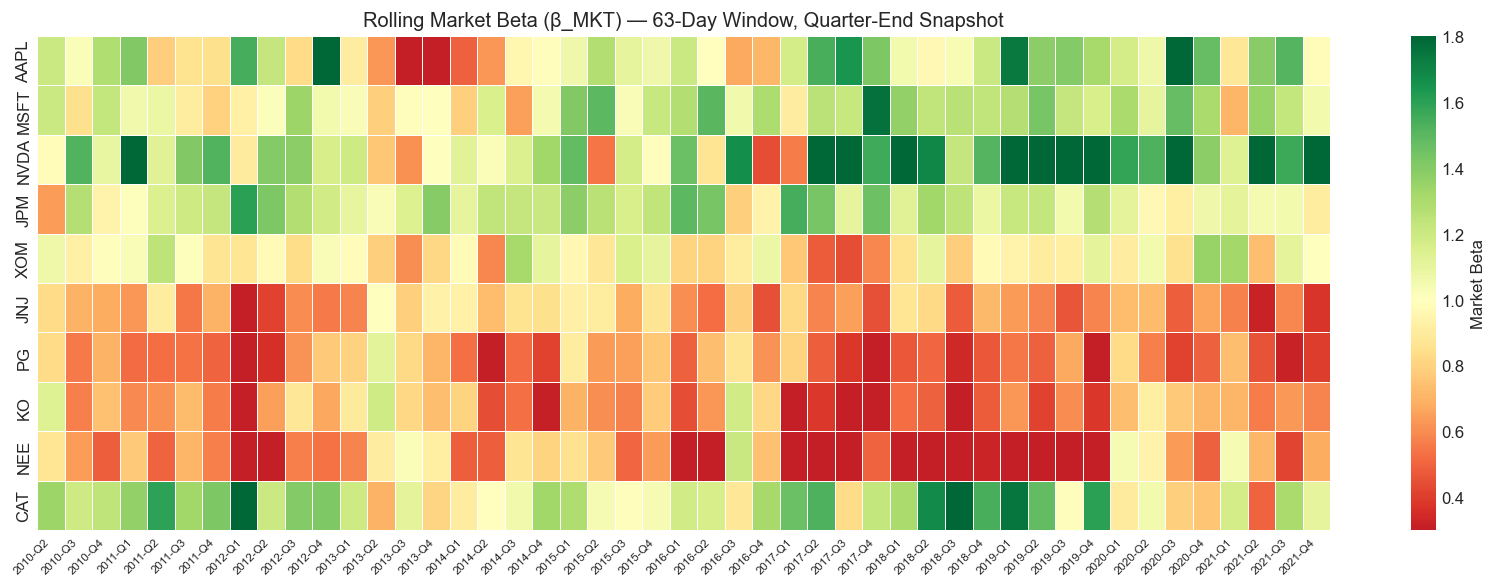

In [15]:
rolling_betas = ff.rolling_betas(train_ret, end_date=train_ret.index[-1])

# Sample at quarter ends for a cleaner heatmap
mkt_betas = rolling_betas['beta_mkt'].resample('QE').last().dropna(how='all')

fig, ax = plt.subplots(figsize=(14, 5))
sns.heatmap(
    mkt_betas.T,
    ax=ax,
    cmap='RdYlGn',
    center=1.0,
    vmin=0.3, vmax=1.8,
    cbar_kws={'label': 'Market Beta'},
    xticklabels=[d.to_period("Q").strftime("%Y-Q%q") for d in mkt_betas.index],
    yticklabels=True,
    linewidths=0.3,
)
ax.set_title('Rolling Market Beta (β_MKT) — 63-Day Window, Quarter-End Snapshot')
plt.xticks(rotation=45, ha='right', fontsize=7)
plt.tight_layout()
plt.show()

### 3d. Quarterly Factor Exposures

MultiIndex columns (output, ticker):
[('alpha_ann', 'AAPL'), ('alpha_ann', 'MSFT'), ('alpha_ann', 'NVDA'), ('alpha_ann', 'JPM'), ('alpha_ann', 'XOM'), ('alpha_ann', 'JNJ'), ('alpha_ann', 'PG'), ('alpha_ann', 'KO')] ...
Shape: (46, 50)


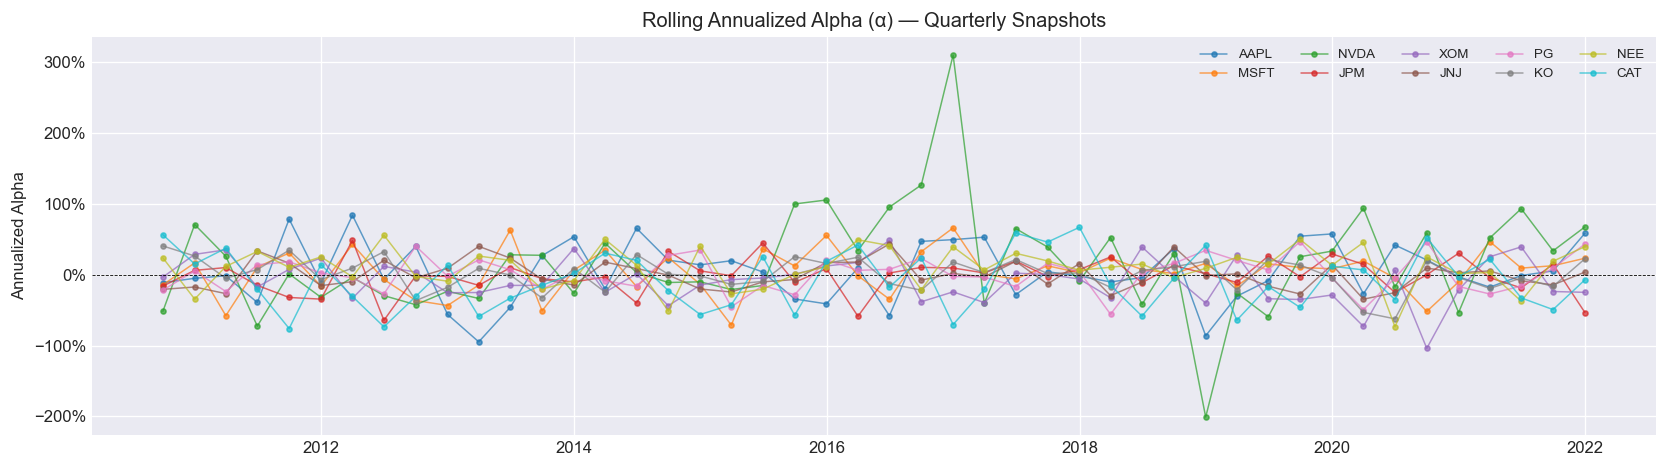

In [16]:
quarterly_betas = ff.forecast_quarterly(train_ret, rebal_train)
print('MultiIndex columns (output, ticker):')
print(quarterly_betas.columns.tolist()[:8], '...')
print(f'Shape: {quarterly_betas.shape}')

# Rolling alpha for all assets
alpha_df = quarterly_betas['alpha_ann']

fig, ax = plt.subplots(figsize=(14, 4))
for col in alpha_df.columns:
    ax.plot(alpha_df.index, alpha_df[col], marker='o', markersize=3,
            linewidth=0.9, alpha=0.7, label=col)
ax.axhline(0, color='black', linewidth=0.5, linestyle='--')
ax.yaxis.set_major_formatter(mtick.PercentFormatter(xmax=1))
ax.set_title('Rolling Annualized Alpha (α) — Quarterly Snapshots')
ax.set_ylabel('Annualized Alpha')
ax.legend(ncol=5, fontsize=8)
plt.tight_layout()
plt.show()

## 4. ForecastBundle — Unified RL State Extension

The `ForecastBundle` packages all three forecasters' quarterly outputs
into a single flat DataFrame via `rl_state_extension`. This is the
quantitative forecasting contribution to the RL state vector.

### 4a. Assemble the Bundle

In [17]:
from forecasting.pipeline import ForecastBundle

# Produce test-period forecasts using in-sample-fitted models
all_returns = pd.concat([train_ret, test_ret])

test_vol    = gf.forecast_quarterly(all_returns, rebal_test)
test_regime = rd.forecast_quarterly(all_returns, rebal_test)
test_betas  = ff.forecast_quarterly(all_returns, rebal_test)

bundle = ForecastBundle(
    fold_idx=0,
    train_dates=rebal_train,    test_dates=rebal_test,
    train_vol=quarterly_vol,    test_vol=test_vol,
    train_regime=quarterly_regime, test_regime=test_regime,
    train_betas=quarterly_betas,   test_betas=test_betas,
    garch_params=params,
    regime_transitions=trans,
)
print(bundle)
ext = bundle.rl_state_extension
print(f'\nrl_state_extension shape: {ext.shape}')
print(f'Columns:')
for col in ext.columns:
    print(f'  {col}')

2026-03-29 15:56:50 [INFO] forecasting.garch: [GARCH] Fitting 10 assets on 3082 observations (2010-01-05 → 2022-03-31)
2026-03-29 15:56:50 [INFO] forecasting.garch: [GARCH] Fit complete: 10/10 converged.
2026-03-29 15:56:50 [INFO] forecasting.garch: [GARCH] Fitting 10 assets on 3333 observations (2010-01-05 → 2023-03-31)
2026-03-29 15:56:50 [INFO] forecasting.garch: [GARCH] Fit complete: 10/10 converged.
2026-03-29 15:56:50 [INFO] forecasting.garch: [GARCH] Fitting 10 assets on 3582 observations (2010-01-05 → 2024-03-28)
2026-03-29 15:56:51 [INFO] forecasting.garch: [GARCH] Fit complete: 10/10 converged.


ForecastBundle(fold=0, train=46Q, test=11Q, n_assets_vol=10)

rl_state_extension shape: (57, 64)
Columns:
  vol_AAPL
  vol_MSFT
  vol_NVDA
  vol_JPM
  vol_XOM
  vol_JNJ
  vol_PG
  vol_KO
  vol_NEE
  vol_CAT
  regime_index
  p_bear
  p_sideways
  p_bull
  alpha_ann_AAPL
  alpha_ann_MSFT
  alpha_ann_NVDA
  alpha_ann_JPM
  alpha_ann_XOM
  alpha_ann_JNJ
  alpha_ann_PG
  alpha_ann_KO
  alpha_ann_NEE
  alpha_ann_CAT
  beta_mkt_AAPL
  beta_mkt_MSFT
  beta_mkt_NVDA
  beta_mkt_JPM
  beta_mkt_XOM
  beta_mkt_JNJ
  beta_mkt_PG
  beta_mkt_KO
  beta_mkt_NEE
  beta_mkt_CAT
  beta_smb_AAPL
  beta_smb_MSFT
  beta_smb_NVDA
  beta_smb_JPM
  beta_smb_XOM
  beta_smb_JNJ
  beta_smb_PG
  beta_smb_KO
  beta_smb_NEE
  beta_smb_CAT
  beta_hml_AAPL
  beta_hml_MSFT
  beta_hml_NVDA
  beta_hml_JPM
  beta_hml_XOM
  beta_hml_JNJ
  beta_hml_PG
  beta_hml_KO
  beta_hml_NEE
  beta_hml_CAT
  r_squared_AAPL
  r_squared_MSFT
  r_squared_NVDA
  r_squared_JPM
  r_squared_XOM
  r_squared_JNJ
  r_squared_PG
  r_squared_KO
  r_

### 4b. State Extension Heatmap

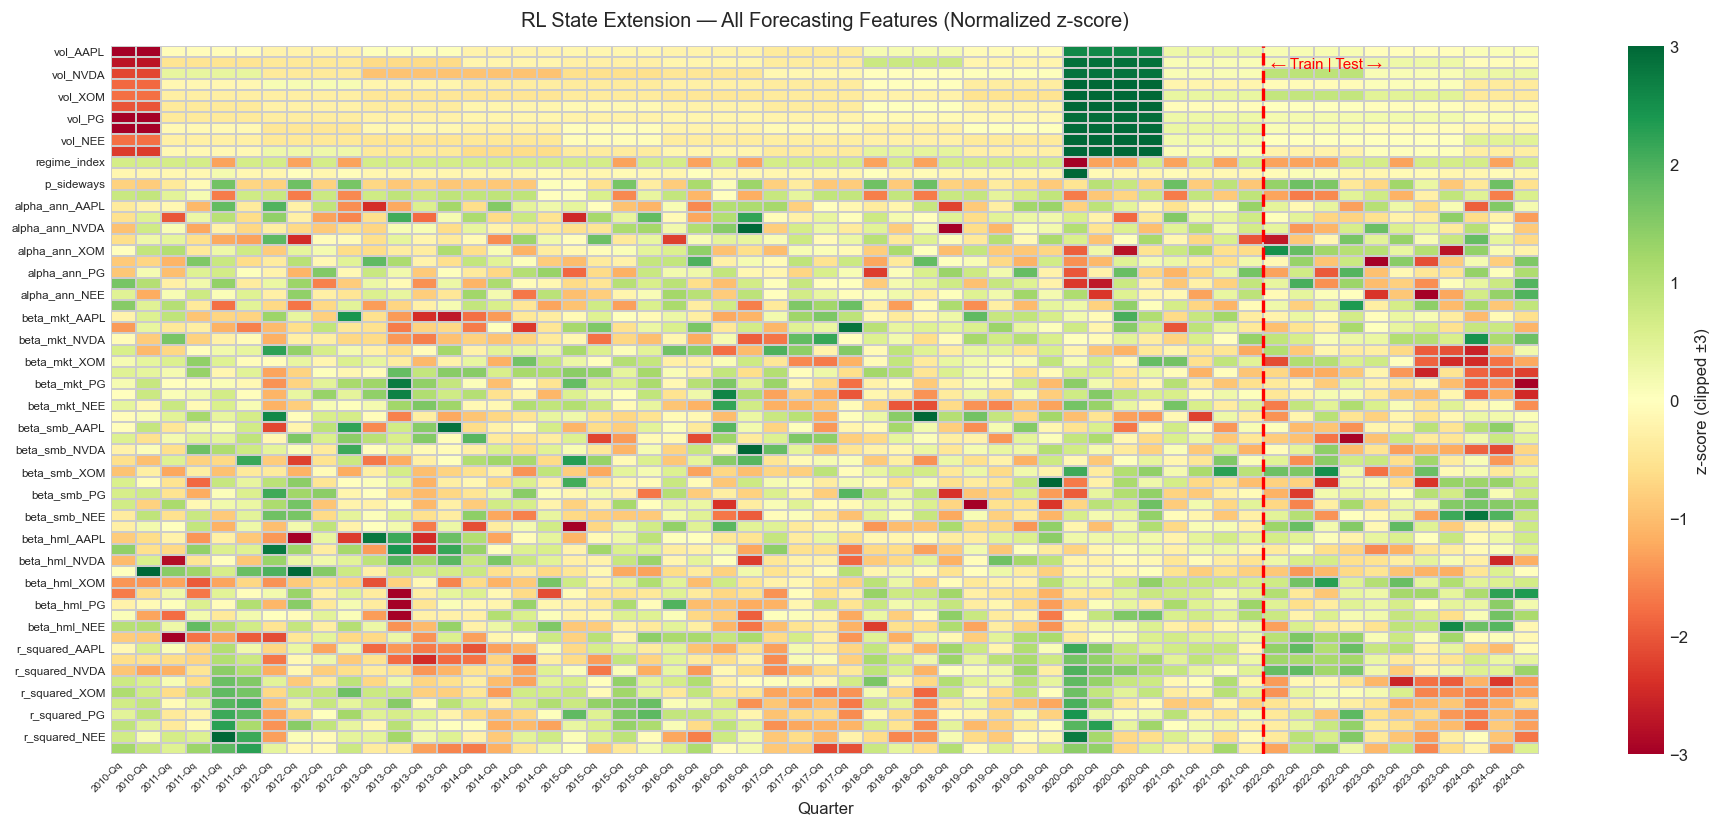


Total features in RL state extension: 64
  GARCH vol features  : 10 (one per asset)
  Regime features     : 4 (index + probabilities)
  Factor beta features: 50


In [18]:
# Normalize for visualization
ext_norm = (ext - ext.mean()) / (ext.std() + 1e-9)
ext_norm = ext_norm.clip(-3, 3)

fig, ax = plt.subplots(figsize=(16, 7))
sns.heatmap(
    ext_norm.T,
    ax=ax,
    cmap='RdYlGn',
    center=0,
    cbar_kws={'label': 'z-score (clipped ±3)'},
    xticklabels=[d.strftime('%Y-Q%q') for d in ext_norm.index],
    linewidths=0.1,
    linecolor='#cccccc',
)

# Mark train/test boundary
split_pos = (ext.index <= split_date).sum()
ax.axvline(split_pos, color='red', linewidth=2, linestyle='--')
ax.text(split_pos + 0.3, 1, '← Train | Test →',
        color='red', fontsize=9, va='top')

ax.set_title('RL State Extension — All Forecasting Features (Normalized z-score)', pad=12)
ax.set_xlabel('Quarter')
plt.xticks(rotation=45, ha='right', fontsize=6)
plt.yticks(fontsize=7)
plt.tight_layout()
plt.show()

print(f'\nTotal features in RL state extension: {ext.shape[1]}')
print(f'  GARCH vol features  : {len([c for c in ext.columns if c.startswith("vol_")])} (one per asset)')
print(f'  Regime features     : {len([c for c in ext.columns if "regime" in c or c.startswith("p_")])} (index + probabilities)')
print(f'  Factor beta features: {len([c for c in ext.columns if "beta" in c or "alpha" in c or "r_squared" in c])}')

## 5. GPU Acceleration Notes

All three forecasting components support GPU acceleration transparently.
The table below summarizes which operations run on GPU and their expected speedup.

In [19]:
import subprocess, sys

# Check GPU availability
try:
    import cupy as cp
    gpu_info = cp.cuda.runtime.getDeviceProperties(0)
    gpu_name = gpu_info['name'].decode()
    gpu_mem  = gpu_info['totalGlobalMem'] / 1024**3
    gpu_available = True
    print(f'GPU detected: {gpu_name} ({gpu_mem:.1f} GB)')
except ImportError:
    gpu_available = False
    print('CuPy not installed → CPU-only mode active.')
    print('Install GPU support: pip install cupy-cuda12x  (match your CUDA version)')

print()
rows = [
    ('GARCHForecaster', 'Batch variance recursion', 'CuPy vectorized loop', '8–20×'),
    ('GARCHForecaster', 'Multi-step aggregation',   'CuPy cumsum',          '10–25×'),
    ('RegimeDetector',  'Viterbi decoding',         'CuPy trellis DP',      '5–15×'),
    ('RegimeDetector',  'Log emission proba',       'CuPy broadcast matmul','10–20×'),
    ('FamaFrenchFactors','Rolling OLS (all assets)','CuPy einsum + solve',  '8–15×'),
]
print(f'{"Component":<22} {"Operation":<35} {"GPU Method":<28} {"Expected Speedup"}')
print('-' * 100)
for r in rows:
    print(f'{r[0]:<22} {r[1]:<35} {r[2]:<28} {r[3]}')

CuPy not installed → CPU-only mode active.
Install GPU support: pip install cupy-cuda12x  (match your CUDA version)

Component              Operation                           GPU Method                   Expected Speedup
----------------------------------------------------------------------------------------------------
GARCHForecaster        Batch variance recursion            CuPy vectorized loop         8–20×
GARCHForecaster        Multi-step aggregation              CuPy cumsum                  10–25×
RegimeDetector         Viterbi decoding                    CuPy trellis DP              5–15×
RegimeDetector         Log emission proba                  CuPy broadcast matmul        10–20×
FamaFrenchFactors      Rolling OLS (all assets)            CuPy einsum + solve          8–15×


## 6. Next Steps

With the `forecasting` module producing quarterly GARCH vol, HMM regime
probabilities, and Fama-French factor exposures, the next modules are:

1. **`agents/`** — LangGraph multi-agent LLM system:
   - Macro Agent: FRED signals + web search → macro sentiment score
   - Sector Agent: earnings transcripts + news → sector outlook
   - Company Agent: SEC EDGAR XBRL + MD&A text → per-stock brief
   - Orchestrator Agent: unified JSON market brief for RL state

2. **`tax/`** — FIFO lot tracker + tax cost calculator (short/long-term rates)

3. **`rl/`** — Custom Gymnasium environment:
   - State vector: data features + forecasting features + LLM embeddings
   - Differential Sharpe Ratio reward with tax and turnover penalties
   - PPO agent via Stable-Baselines3 (GPU-accelerated via PyTorch CUDA)